In [5]:
from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END 
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from typing import TypedDict, List, Annotated
from dotenv import load_dotenv

load_dotenv()


llm = ChatOpenAI(model="gpt-4o-mini")


# Define tools
@tool
def multiplier(num1:int,  num2:int)->int:
    """ Add multiply numbers"""

    return num1 * num2 

@tool 
def weather_update(city:str)->str:
    """ Get the weather of a place"""

    return f"{city} is sunny at this time of the year"

tools = [multiplier, weather_update]

llm_with_tools =  llm.bind_tools(tools)

class AgentState(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

# define the node functions

def chatBot(state:AgentState):
    """ Chat with the agent"""

    response = llm_with_tools.invoke(state['messages'])

    return {
        "messages": [response]
    }

tool_node =ToolNode(tools)

def should_continue(state:AgentState):
    """Decide whether to call a tool or end"""
    last_message = state['messages'][-1] #get the last message
    # if the last message indicate the llm wants to call a tool
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tool"
    return END

#generate nodes

graph = StateGraph(AgentState)

graph.add_node("chatbot", chatBot)
graph.add_node("tool_node", tool_node)

#add edges
graph.add_edge(START, "chatbot")
graph.add_conditional_edges(
    "chatbot",
    should_continue,
    {
        "tool": "tool_node",
        END: END
    }
)

graph.add_edge("tool_node","chatbot")

# add memory
memory = MemorySaver()
app = graph.compile(checkpointer=memory)




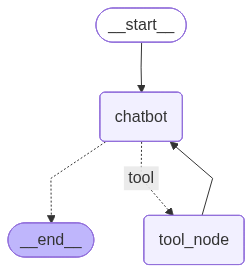

In [6]:
app

In [7]:
config = {
    "configurable":{"thread_id": "user1"}
}

# first run
response = app.invoke({
    "messages": [HumanMessage(content="Tell me the weather in Nigeria")]
},
config=config
)

print(response['messages'][-1].content)

The weather in Nigeria is currently sunny.


In [8]:
# second run
response = app.invoke({
    "messages": [HumanMessage(content="multiply 5 b 4")]
},
config=config
)

print(response['messages'][-1].content)

The result of multiplying 5 by 4 is 20.


In [9]:
response = app.invoke({
    "messages": [HumanMessage(content="multiply that by 10")]
},
config=config
)

print(response['messages'][-1].content)

Multiplying 20 by 10 gives you 200.
